# Árvores II - Tarefa 2

### 1. Carregar as bases

Vamos carregar as bases lidas na tarefa passada. Se você salvou essas bases em arquivo texto, basta fazer a leitura com o comando ```pd.read_csv``` das seguintes bases:

- X_train
- Y_train
- X_test
- Y_test

Não se esqueça de considerar a leitura dos índices dos arquivos no ```read_csv()```!

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

### 2. Divisão da base em Treino, Validação e Teste

A base já se encontra dividida em Treino e Validação. O que vamos fazer então é extrair uma base de Validação da base de Treino.

Extraia 25% da base de treino como base de validação.

In [23]:
# =========================================
#  Carregar bases salvas em CSV
# =========================================

X_train = pd.read_csv(
    'X_train_processado.csv',
    index_col=[0,1]
)

X_test = pd.read_csv(
    'X_test_processado.csv',
    index_col=[0,1]
)

# Carregar variáveis resposta
path = r'./UCI HAR Dataset/'

y_train = pd.read_csv(
    path + 'train/y_train.txt',
    header=None,
    names=['atividade']
)

y_test = pd.read_csv(
    path + 'test/y_test.txt',
    header=None,
    names=['atividade']
)

print(X_train.head())
print(X_test.head())


# =========================================
#  Separar treino e validação
# =========================================

X_treino, X_validacao, y_treino, y_validacao = train_test_split(
    X_train,
    y_train,
    test_size=0.25,
    random_state=100,
    stratify=y_train
)

print(X_treino.shape)
print(X_validacao.shape)



                  tBodyAcc-mean()-X  tBodyAcc-mean()-Y  tBodyAcc-mean()-Z  \
registro subject                                                            
0        1                 0.288585          -0.020294          -0.132905   
1        1                 0.278419          -0.016411          -0.123520   
2        1                 0.279653          -0.019467          -0.113462   
3        1                 0.279174          -0.026201          -0.123283   
4        1                 0.276629          -0.016570          -0.115362   

                  subject.1  
registro subject             
0        1                1  
1        1                1  
2        1                1  
3        1                1  
4        1                1  
                  tBodyAcc-mean()-X  tBodyAcc-mean()-Y  tBodyAcc-mean()-Z  \
registro subject                                                            
0        2                 0.257178          -0.023285          -0.014654   
1        2         

### 3. Melhores 3 variáveis

Rode uma árvore com profundidade máxima igual a 4 para prever a atividade humana com todas as variáveis.
Observe a importância das variáveis e considere as 3 variáveis com maior importância para os próximos passos.
Dica: utilize o atributo ```clf.feature_importances_``` da árvore treinada.

In [25]:

# =========================================
#  Árvore com TODAS as variáveis
# =========================================

# Recarregar todas as variáveis originais
features = pd.read_csv(
    path + 'features.txt',
    sep=r'\s+',
    header=None,
    names=['index', 'feature_name']
)

features_series = features['feature_name']

# Base completa treino
X_train_full = pd.read_csv(
    path + 'train/X_train.txt',
    sep=r'\s+',
    header=None
)

X_train_full.columns = features_series.values

# Dividir treino/validação
X_train_full_treino, X_train_full_validacao, y_full_treino, y_full_validacao = train_test_split(
    X_train_full,
    y_train,
    test_size=0.25,
    random_state=100,
    stratify=y_train
)

# Ajustar árvore
clf_full = DecisionTreeClassifier(
    max_depth=4,
    random_state=100
)

clf_full.fit(X_train_full_treino, y_full_treino)

# =========================================
# Importância das variáveis
# =========================================

importancias = pd.DataFrame({
    'variavel': X_train_full.columns,
    'importancia': clf_full.feature_importances_
})

importancias = importancias.sort_values(
    by='importancia',
    ascending=False
)

print(importancias.head(10))

# Selecionar 3 melhores
melhores_3 = importancias.head(3)['variavel'].tolist()

print('\n3 Melhores Variáveis:')
print(melhores_3)



                             variavel  importancia
40               tGravityAcc-mean()-X     0.282909
381    fBodyAccJerk-bandsEnergy()-1,8     0.254259
50                tGravityAcc-max()-Y     0.165666
214              tGravityAccMag-std()     0.136362
73          tGravityAcc-arCoeff()-Z,1     0.126268
159       tBodyGyro-correlation()-Y,Z     0.017116
49                tGravityAcc-max()-X     0.013044
432                 fBodyGyro-max()-X     0.004376
419  fBodyAccJerk-bandsEnergy()-33,48     0.000000
371            fBodyAccJerk-maxInds-Z     0.000000

3 Melhores Variáveis:
['tGravityAcc-mean()-X', 'fBodyAccJerk-bandsEnergy()-1,8', 'tGravityAcc-max()-Y']


### 4. Construa uma árvore com as 3 melhores variáveis

Utilizando as três variáveis encontradas acima, construa uma árvore de decisão. Encontre o melhor ```ccp_alpha``` utilizando a base de validação, conforme a estrutura que vimos em aula.


Quantidade de alphas: 18
   ccp_alpha  acc_treino  acc_validacao
0   0.000000    0.903881       0.860174
1   0.000010    0.903881       0.860174
2   0.000015    0.903881       0.860174
3   0.000050    0.903881       0.860174
4   0.000093    0.903881       0.860174


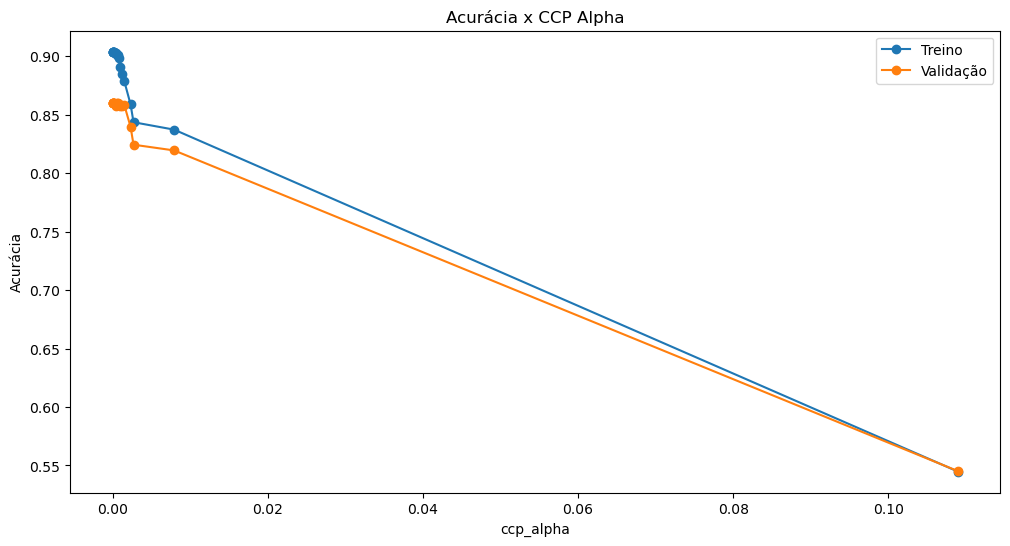


Melhor ccp_alpha: 0.0
CPU times: total: 1.41 s
Wall time: 1.52 s


In [27]:
%%time
# =========================================
#  Construir árvore com 3 melhores variáveis
# =========================================

X_treino_3 = X_train_full_treino[melhores_3]
X_validacao_3 = X_train_full_validacao[melhores_3]

# Árvore inicial
clf = DecisionTreeClassifier(
    random_state=100,
    min_samples_leaf=20
)

clf.fit(X_treino_3, y_full_treino)

# CCP Alphas
path_ccp = clf.cost_complexity_pruning_path(
    X_treino_3,
    y_full_treino
)

ccp_alphas = path_ccp.ccp_alphas

# Apenas positivos e únicos
ccp_alphas = ccp_alphas[ccp_alphas >= 0]
ccp_alphas = np.unique(ccp_alphas)

# Pegar 1 a cada 5
ccp_alphas = ccp_alphas[::5]

print(f'\nQuantidade de alphas: {len(ccp_alphas)}')

# =========================================
# Treinar árvore para cada alpha
# =========================================

train_scores = []
valid_scores = []
arvores = []

for alpha in ccp_alphas:

    clf_alpha = DecisionTreeClassifier(
        random_state=100,
        min_samples_leaf=20,
        ccp_alpha=alpha
    )

    clf_alpha.fit(X_treino_3, y_full_treino)

    arvores.append(clf_alpha)

    # Predições
    pred_train = clf_alpha.predict(X_treino_3)
    pred_valid = clf_alpha.predict(X_validacao_3)

    # Acurácia
    acc_train = accuracy_score(y_full_treino, pred_train)
    acc_valid = accuracy_score(y_full_validacao, pred_valid)

    train_scores.append(acc_train)
    valid_scores.append(acc_valid)

# =========================================
#  Resultados
# =========================================

resultados = pd.DataFrame({
    'ccp_alpha': ccp_alphas,
    'acc_treino': train_scores,
    'acc_validacao': valid_scores
})

print(resultados.head())


# =========================================
# Gráfico
# =========================================

plt.figure(figsize=(12,6))

plt.plot(
    resultados['ccp_alpha'],
    resultados['acc_treino'],
    marker='o',
    label='Treino'
)

plt.plot(
    resultados['ccp_alpha'],
    resultados['acc_validacao'],
    marker='o',
    label='Validação'
)

plt.xlabel('ccp_alpha')
plt.ylabel('Acurácia')
plt.title('Acurácia x CCP Alpha')
plt.legend()

plt.show()


# =========================================
# Melhor árvore
# =========================================

melhor_idx = resultados['acc_validacao'].idxmax()

melhor_alpha = resultados.loc[melhor_idx, 'ccp_alpha']

print(f'\nMelhor ccp_alpha: {melhor_alpha}')

### 5. Avaliação do modelo

Avalie a árvore encontrada no item anterior na base de testes.

In [31]:
# =========================================
# Avaliação na base de teste
# =========================================

# Base completa de teste
X_test_full = pd.read_csv(
    path + 'test/X_test.txt',
    sep=r'\s+',
    header=None
)

X_test_full.columns = features_series.values

# Selecionar melhores variáveis
X_test_3 = X_test_full[melhores_3]

# Melhor árvore
melhor_arvore = arvores[melhor_idx]

# Predição teste
pred_test = melhor_arvore.predict(X_test_3)

# Acurácia teste
acc_test = accuracy_score(y_test, pred_test)

print(f'\nAcurácia na base de teste: {acc_test:.4f}')


Acurácia na base de teste: 0.7275
